### Event Definition

Add an explanation of the workflow
example color green needs user input, color yellow can be changed by the user, color red must not be touched by the user

In [1]:
# Imports
from c3s_lib import *
import requests
import urllib.parse
import matplotlib.pyplot as plt
import cartopy 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import json
import geopandas as gpd
import rasterio
from rasterio import features
from shapely.geometry import shape, Polygon, mapping, MultiPolygon, GeometryCollection
from shapely.vectorized import contains # replace with below
from shapely import contains_xy
import xarray as xr
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from shapely.ops import unary_union
from datetime import datetime, timedelta
import pandas as pd
import contextily as ctx
import math
import regionmask
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import cmocean
import base64
from io import BytesIO
import contextily as ctx
from typing import Union, Literal
import os


### 2.1 Please specify the following variables below to start the workflow

In [2]:
# Api key used for the DataClient, replace with your own API key from the C3S Climate Data Store
your_api_key = '98256e82-4de4-4cc1-8087-faebb5c2e4ae'

# Directory you wish to store output files in. using ../ specifies the parent directory
CURRENT_DIRECTORY = os.getcwd() # do not touch, __file__ specifies the current directory of the file
your_save_directory = CURRENT_DIRECTORY + "your prefered directory"

# Area of interest (min lon, min lat, max lon, max lat)
bbox = (-110, 18, -95, 32)

# Date of the event
event_date = datetime(2024, 6, 7)
 # Date of days leading up to the event
event_start = event_date - timedelta(days=14)

# Choice of parameter (Tmax, Tmean, Tmin, Precipitation)
parameter = "Tmean"

### 2.2.a.i Obtaining climatology (daily values) for period 1950 - event for chosen parameter

In [3]:
# climatology_1950_event = DataClient(your_api_key, beacon_cache_url='https://beacon-development.maris.nl').temperature_2m_mean(bbox, (datetime(1951, 1, 1), event_date))
climatology_1950_event = DataClient(your_api_key, beacon_cache_url='https://beacon-development.maris.nl').GET(parameter=parameter, bbox=bbox, time_range=(datetime(1951,1,1), event_date))
climatology_1950_event.head()

2025-09-22 10:50:01,633 WARNING [2025-09-19T00:00:00] Scheduled System Session affecting Service reliability - 22 September 2025. Please follow status [here](https://status.ecmwf.int/) or in our [forum](https://forum.ecmwf.int/t/scheduled-maintenance-of-the-cloud-infrastructure-on-22-september-2025/14173)
2025-09-22 10:50:01,633 INFO [2025-09-03T00:00:00] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.
2025-09-22 10:50:01,633 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.


Connected to: https://beacon-development.maris.nl/ server successfully
Connected to: https://beacon-development.maris.nl/ server successfully
Fetching data from beacon cache...
Beacon Bbox: (250.0, 18, 265.0, 32)
Running query: {"from": "era5_daily_mean_2m_temperature", "select": [{"column": "longitude", "alias": null}, {"column": "latitude", "alias": null}, {"column": "valid_time", "alias": null}, {"column": "t2m", "alias": null}], "filters": [{"and": [{"column": "longitude", "gt_eq": 250.0, "lt_eq": null}, {"column": "longitude", "gt_eq": null, "lt_eq": 265.0}, {"column": "latitude", "gt_eq": 18, "lt_eq": null}, {"column": "latitude", "gt_eq": null, "lt_eq": 32}]}, {"column": "valid_time", "gt_eq": "1951-01-01T00:00:00.000000", "lt_eq": "2024-06-07T00:00:00.000000"}], "output": {"format": "parquet"}}
Beacon cache covers time range: 1951-01-01 00:00:00 - 2024-06-07 00:00:00


,longitude,latitude,valid_time,t2m,geometry
0,-110.0,18.00,1951-01-01,23.174316,POINT (-110 18)
1,-110.0,18.25,1951-01-01,23.179443,POINT (-110 18.25)
2,-110.0,18.50,1951-01-01,23.130859,POINT (-110 18.5)
3,-110.0,18.75,1951-01-01,23.048492,POINT (-110 18.75)
4,-110.0,19.00,1951-01-01,22.917786,POINT (-110 19)


### 2.2 Please specify the gpd columns below

In [4]:
# Value column
value_col = 't2m'

#Datetime column
datetime_col = 'valid_time'

### 2.2.a.i Select Subsets

In [5]:
# Sort gdf, this is needed when the era5 set gets merged with the beacon set
climatology_1950_event = climatology_1950_event.sort_values(by=datetime_col)

# Specifiy climatology dates
climatology_1991_date = datetime(1991, 1, 1)
climatology_2020_date = datetime(2020, 12, 31)

# Select event subset
climatology_event = subset_gdf(gdf=climatology_1950_event, datetime_col=datetime_col, date_range=(event_start, event_date))

# Select climatology subset
climatology_1991_2020 = subset_gdf(gdf=climatology_1950_event, datetime_col=datetime_col, date_range=(climatology_1991_date, climatology_2020_date))

# needs a better print of the resulting dataframes
print(climatology_1991_2020)
print(climatology_event)

          longitude  latitude valid_time        t2m            geometry
50801289     -100.0     27.75 1991-01-01   9.296753  POINT (-100 27.75)
50801288     -100.0     27.50 1991-01-01   9.264465   POINT (-100 27.5)
50801287     -100.0     27.25 1991-01-01   9.330139  POINT (-100 27.25)
50801286     -100.0     27.00 1991-01-01   9.323059     POINT (-100 27)
50801281     -100.0     25.75 1991-01-01  10.110168  POINT (-100 25.75)
...             ...       ...        ...        ...                 ...
88897618     -105.0     22.75 2020-12-31   7.567627  POINT (-105 22.75)
88897617     -105.0     22.50 2020-12-31   8.966492   POINT (-105 22.5)
88897616     -105.0     22.25 2020-12-31  11.049011  POINT (-105 22.25)
88897615     -105.0     22.00 2020-12-31  13.906586     POINT (-105 22)
88897619     -105.0     23.00 2020-12-31   5.122070     POINT (-105 23)

[38100966 rows x 5 columns]
          longitude  latitude valid_time        t2m            geometry
93210259     -100.0     28.00 2024-

### 2.2.a.i Plotting figure of 15 maps for 15 days up to and including the event of the chosen variable.

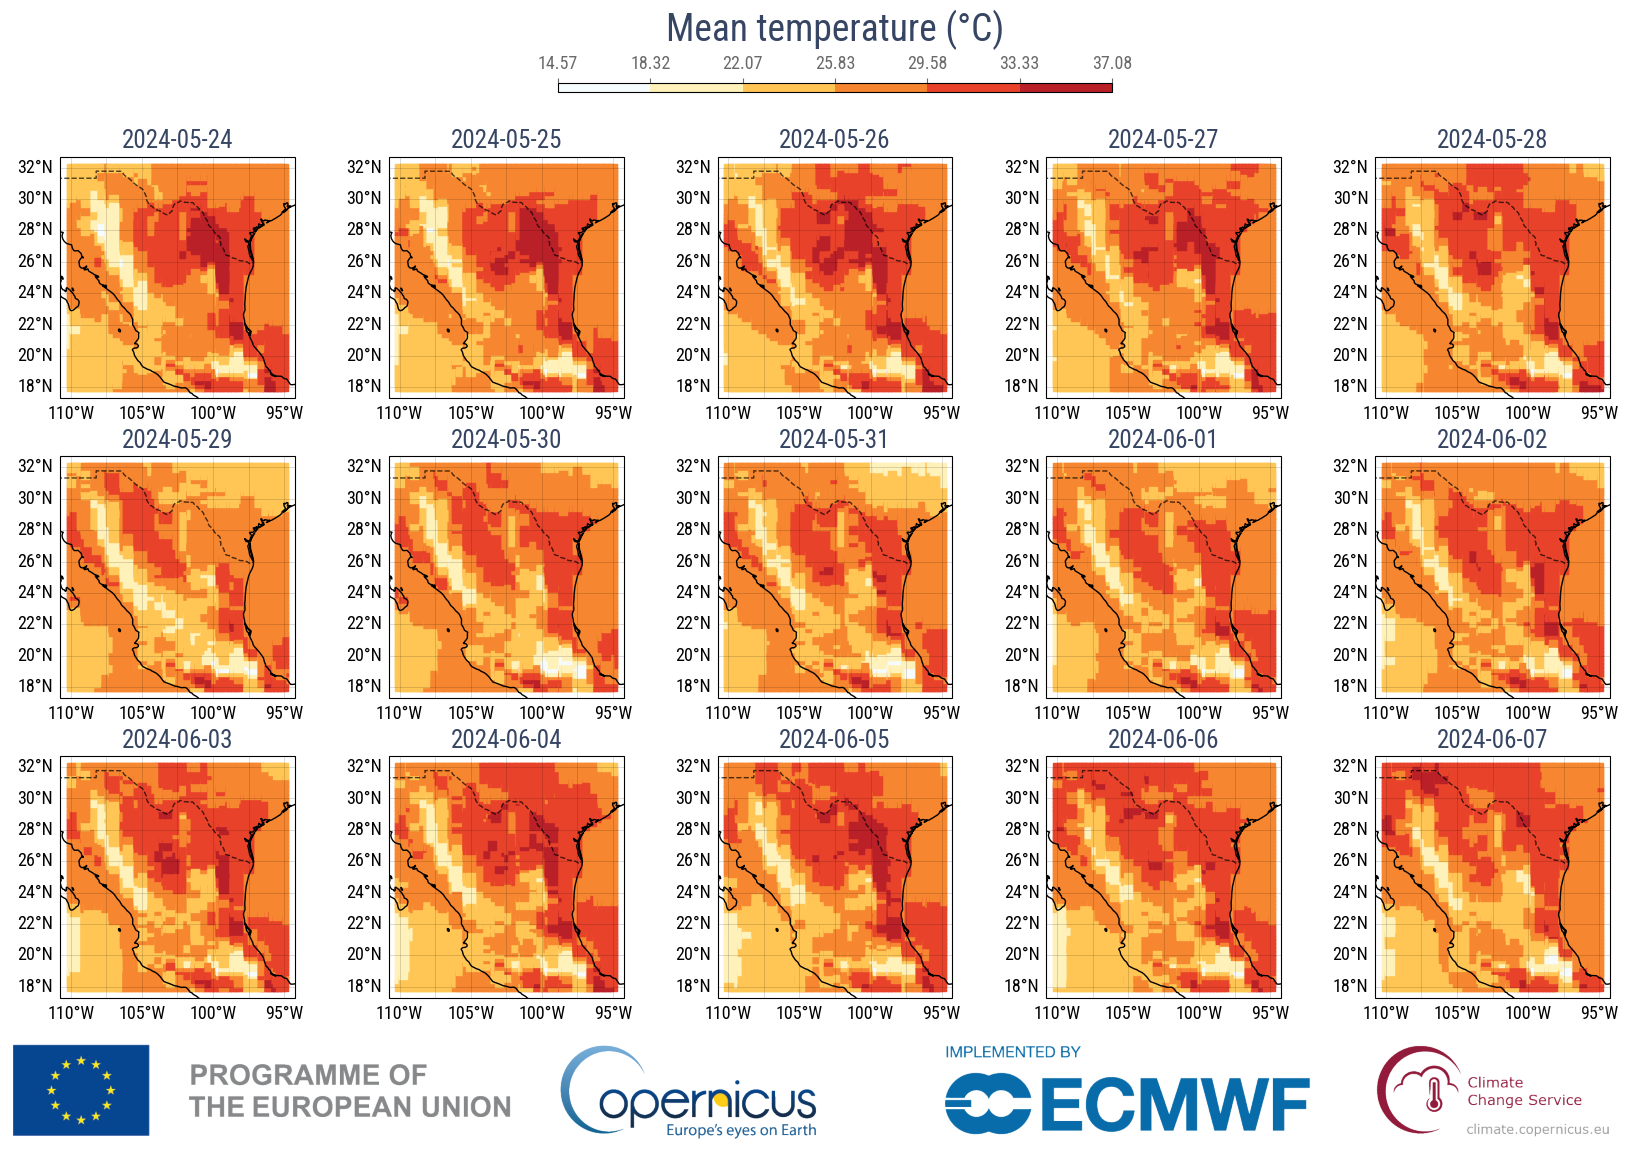

In [6]:
#2.2.a.i Plotting figure of 15 maps for 15 days up to and including the event of the chosen variable.
fig, axes, img_ax = subplot_gdf(climatology_event, datetime_col=datetime_col, value_col=value_col, ncols=5, legend_title='Mean temperature (°C)')

### 2.2.a.ii Calculating the 30-day smoothed climatology for 1991-2020 and slicing out the event days

In [7]:
# Calculate 30 smoothed mean for 1991-2020
mean_climatology_1991_2020 = calculate_climatology(climatology_1991_2020, value_col=value_col, padding=15)

mean_climatology_event = subset_gdf(gdf=mean_climatology_1991_2020, datetime_col=datetime_col, doy_range=(event_start.timetuple().tm_yday, event_date.timetuple().tm_yday))
mean_climatology_event

,longitude,latitude,t2m,doy,geometry,valid_time
500688,-110.0,18.00,23.953434,145,POINT (-110 18),2024-05-24
500689,-110.0,18.25,23.766436,145,POINT (-110 18.25),2024-05-24
500690,-110.0,18.50,23.582802,145,POINT (-110 18.5),2024-05-24
500691,-110.0,18.75,23.381704,145,POINT (-110 18.75),2024-05-24
500692,-110.0,19.00,23.176945,145,POINT (-110 19),2024-05-24
...,...,...,...,...,...,...
552838,-95.0,31.00,26.707762,159,POINT (-95 31),2024-06-07
552839,-95.0,31.25,26.600462,159,POINT (-95 31.25),2024-06-07
552840,-95.0,31.50,26.477228,159,POINT (-95 31.5),2024-06-07
552841,-95.0,31.75,26.372051,159,POINT (-95 31.75),2024-06-07


### 2.2.a.ii Plotting figure of 15 maps for 15 days up to and including the event of the chosen variable's anomaly with respect to the 1991-2020 30-day running mean of the daily climatology.

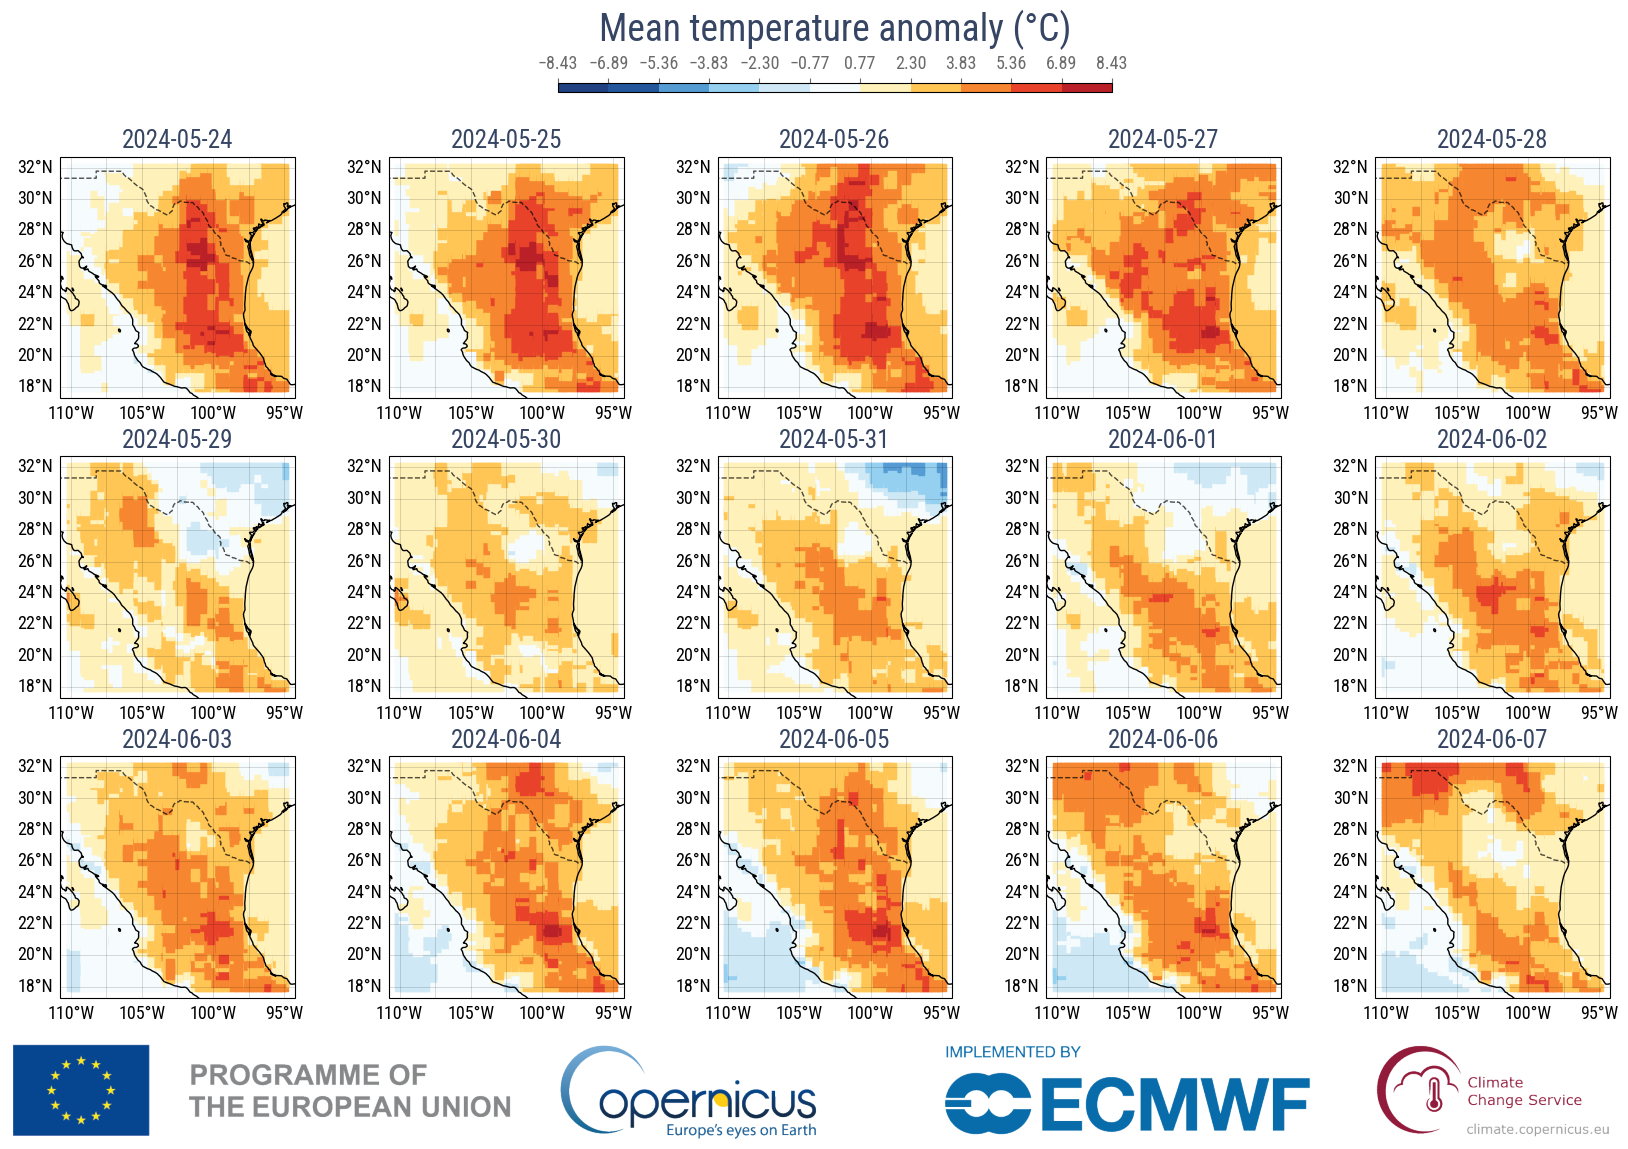

In [8]:
# Calculate the anomoly for the days leading up to the event
event_anomaly = calculate_anomaly(event_gdf=climatology_event, mean_climatology_gdf=mean_climatology_event, value_col=value_col, datetime_col=datetime_col, calcation='subtract')
fig, axes, img_ax = subplot_gdf(event_anomaly,datetime_col=datetime_col, value_col=value_col, ncols=5, legend_title='Mean temperature anomaly (°C)')

### 2.2.b Choose one day for the overlay of the regions in steps 2c-2g.

In [9]:
# Selected date
selected_date = datetime(2024, 5, 26)

### 2.2.c & 2.2.d Define type of region and level by visually inspecting the single map over the event region and select regions to be combined into one spatial event definition.

The region picker will shortly open in your web browser. Please select a region, close the browser tab and return to the notebook when done.
Region Picker started successfully for wraf:
Polling for region selection...
Region selection process done.
Received polygon data:
{"type":"FeatureCollection","features":[{"type":"Feature","properties":{"merge_key":"1"},"geometry":{"type":"Polygon","coordinates":[[[-107.125,25.125],[-107.083,25.125],[-107.083,25],[-107.042,25],[-107.042,24.9167],[-107,24.9167],[-107,24.875],[-106.958,24.875],[-106.958,24.7917],[-106.833,24.7917],[-106.833,24.75],[-106.792,24.75],[-106.792,24.7083],[-106.75,24.7083],[-106.75,24.6667],[-106.708,24.6667],[-106.708,24.5833],[-106.667,24.5833],[-106.667,24.5417],[-106.625,24.5417],[-106.625,24.375],[-106.583,24.375],[-106.583,24.3333],[-106.542,24.3333],[-106.542,24.2917],[-106.375,24.2917],[-106.375,24.3333],[-106.333,24.3333],[-106.333,24.375],[-106.292,24.375],[-106.292,24.4167],[-106.208,24.4167],[-106.208,24.375],

c:\Python310\lib\site-packages\xarray\coding\times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 0:0:0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 0:0:0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
C:\Users\jasper\AppData\Local\Temp\ipykernel_18032\3002700299.py:16: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  elevation_nc = xr.open_dataset("../data/elev.0.25-deg.nc")


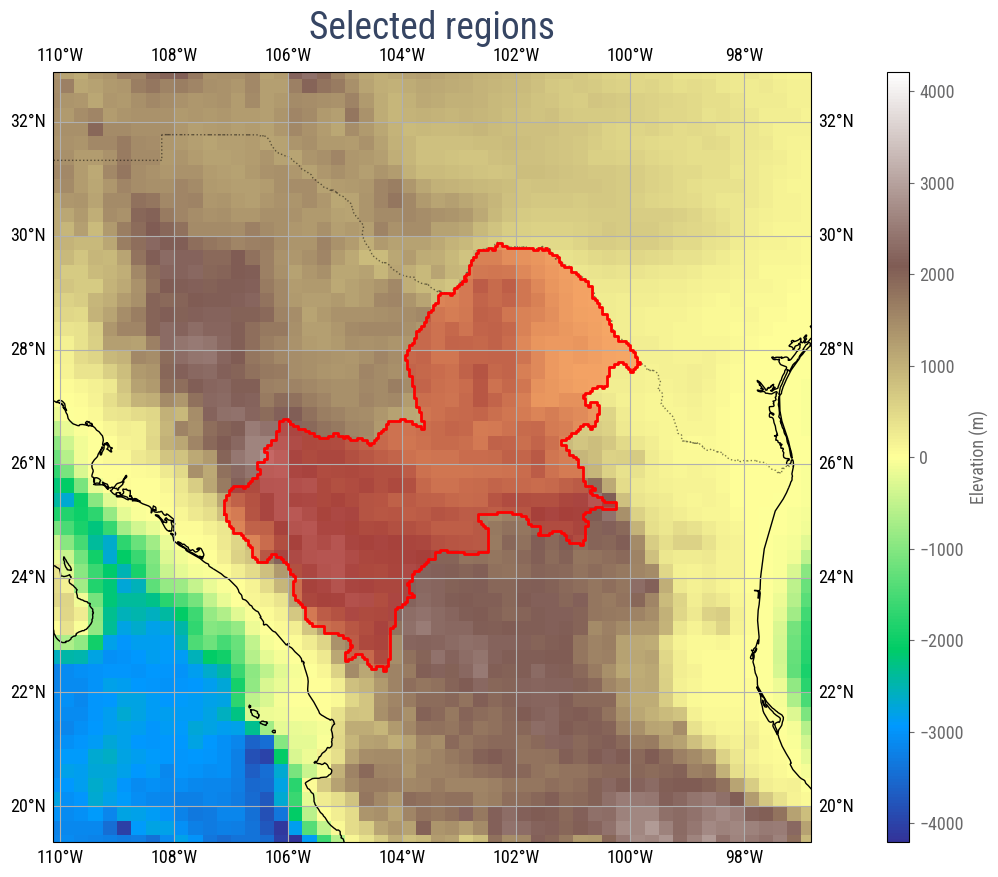

In [10]:
# all this needs to be turned into a single function

# Overlay images
anomaly_img = get_base_fig(selected_date, event_anomaly, value_col=value_col)      # Anomaly
event_img = get_base_fig(selected_date, climatology_event, value_col=value_col)  # Event
overlays = {
    "anomaly": anomaly_img,
    "event": event_img
}

result = select_region(regionType='wraf', bbox=bbox, overlays=overlays) # regiontype wraf for temperature, hydrobasin for precipitation
data = json.loads(result)

polygons, coords = data_2_poly(data)

elevation_nc = xr.open_dataset("../data/elev.0.25-deg.nc")
elevation = wrap_lon(elevation_nc)['data']

fig, ax = plot_poly(polygons, coords, elevation=elevation)

### 2.2.e Use topography overlay to decide whether to cut off area above a specified height level

#### Please select an elevation threshold

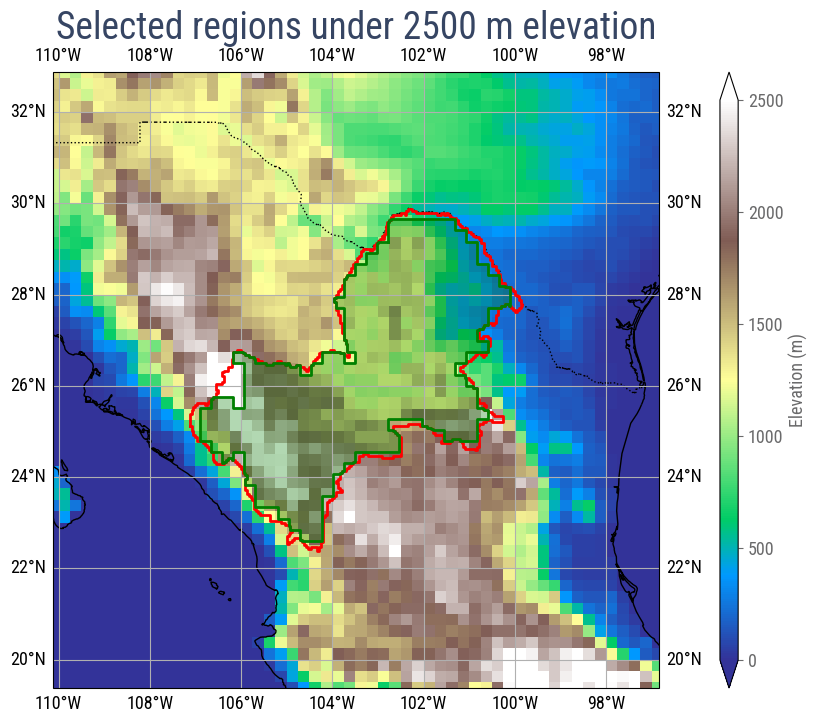

In [11]:
elevation_threshold = 2500  # meters

fig, ax, adjusted_polygons = elevation_region(data, polygons, elevation, elevation_threshold)

### 2.3 Save study domain for use in other parts of the software


In [12]:
multipoly = unary_union(adjusted_polygons)
studyregion = gpd.GeoDataFrame(index=[0], crs='EPSG:4326', geometry=[multipoly])    #is this using the correct CRS?
studyregion.to_file("../data/sf_studyregion.shp")
#polygons_gdf = gpd.GeoDataFrame(geometry=polygons, crs="EPSG:4326")
#polygons_gdf.to_file("../data/sf_polygons.shp")

### 2.4 Create daily time series of the required variable by averaging over the study domain

In [13]:
# climatology_1950_event_studyregion = gpd.overlay(climatology_1950_event, studyregion, how='intersection')
climatology_1950_event_studyregion = subset_gdf(gdf=climatology_1950_event, study_region=studyregion)

climatology_1950_event_studyregion_weighted = weighted_values(climatology_1950_event_studyregion, value_col)

spatialmean_climatology_1950_event_studyregion = calculate_mean(gdf= climatology_1950_event_studyregion_weighted,
                                                                value_col=value_col, groupby_col=datetime_col)

#spatialmean_climatology_1950_event_studyregion = climatology_1950_event_studyregion.groupby(datetime_col)[value_col].mean().reset_index()
spatialmean_climatology_1950_event_studyregion.to_xarray().to_netcdf("../data/mean_temperature.nc")
spatialmean_climatology_1950_event_studyregion

,valid_time,t2m
0,1951-01-01,12.480233
1,1951-01-02,13.768643
2,1951-01-03,8.222716
3,1951-01-04,10.038460
4,1951-01-05,11.650063
...,...,...
26817,2024-06-03,28.805435
26818,2024-06-04,29.002833
26819,2024-06-05,29.224817
26820,2024-06-06,28.377722


### 2.5 Compare n-day accumulations (precipitation) or n-day averages (temperature) for the current year to the seasonal cycle of the same

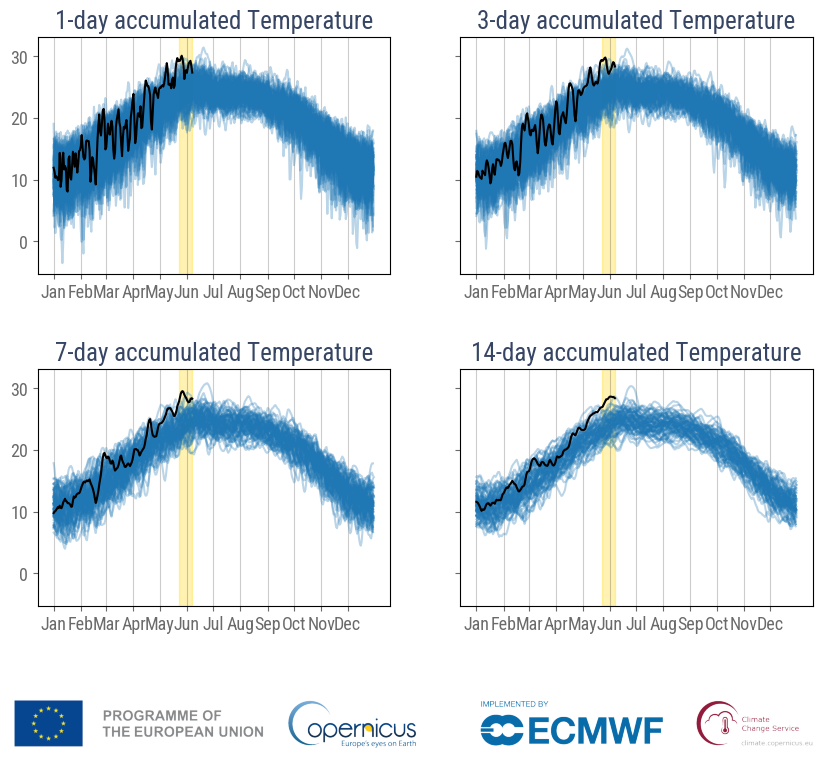

In [14]:
days = [1, 3, 7, 14] #temperature (t2m): days = [1, 3, 7, 14] & precipitation (tp): days = [1, 3, 5, 10]
rolled_data_list = [calculate_running_mean(gdf = spatialmean_climatology_1950_event_studyregion, value_col=value_col, datetime_col=datetime_col, padding=d, centering=False, method='mean') for d in days]
labelticks = pd.date_range("2000-01-01", "2000-12-31", freq="MS").dayofyear
labels = pd.date_range("2000-01-01", "2000-12-31", freq="MS").strftime("%b")

fig, axes, img_ax = plot_n_day_accumulations(rolled_data_list,value_col=value_col,parameter="Temperature",event_date=event_date,labelticks=labelticks,labels=labels,days=days,ylimit=None,fig_height=4, ncols=2)

### 2.6 Calculate seasonal cycle over years 1991-2020

In [15]:
mean_climatology_1991_2020_studyregion = subset_gdf(gdf=mean_climatology_1991_2020, study_region=studyregion)
mean_climatology_1991_2020_studyregion[datetime_col] = pd.to_datetime('2024', format='%Y') + pd.to_timedelta(mean_climatology_1991_2020_studyregion['doy'] - 1, unit='D')

mean_climatology_1991_2020_studyregion_weighted = weighted_values(mean_climatology_1991_2020_studyregion, value_col)

mean_climatology_1991_2020_studyregion_spatialmean = calculate_mean(gdf= mean_climatology_1991_2020_studyregion_weighted,
                                                                value_col=value_col, groupby_col=datetime_col)

#mean_climatology_1991_2020_studyregion_spatialmean = mean_climatology_1991_2020_studyregion.groupby(datetime_col)[value_col].mean().reset_index()
mean_climatology_1991_2020_studyregion_spatialmean

,valid_time,t2m
0,2024-01-01,11.278104
1,2024-01-02,11.272915
2,2024-01-03,11.261179
3,2024-01-04,11.247681
4,2024-01-05,11.260046
...,...,...
360,2024-12-26,11.427748
361,2024-12-27,11.400965
362,2024-12-28,11.364277
363,2024-12-29,11.308511


### 2.6 Plot seasonal cycle over years 1991-2020

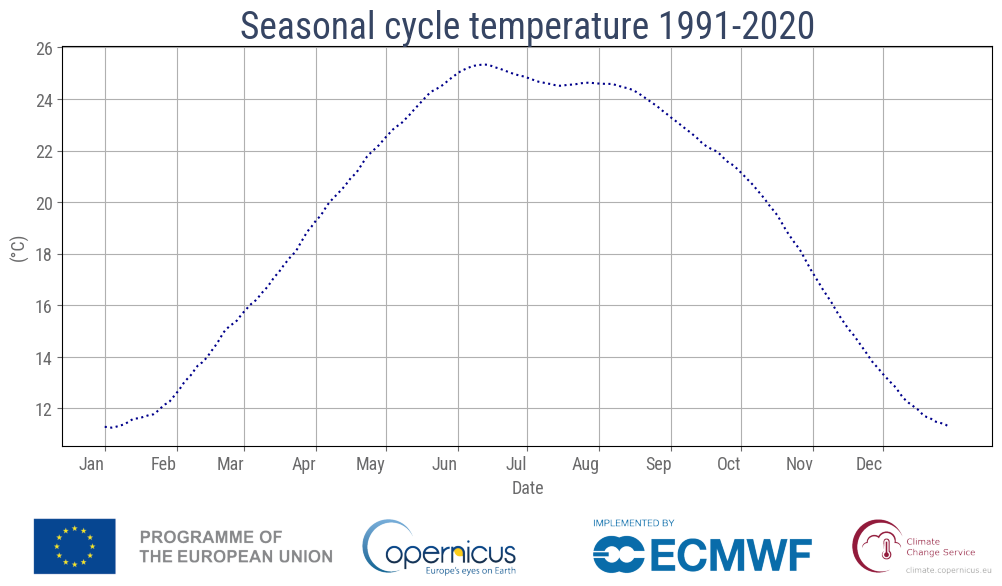

In [16]:
labelticks = pd.date_range("2024-01-01", "2024-12-31", freq="MS")
labels = labelticks.strftime("%b")
fig, ax, img_ax= plot_timeserie(data=mean_climatology_1991_2020_studyregion_spatialmean, value_col='t2m', title='Seasonal cycle temperature 1991-2020', x_label='Date', y_label='(°C)', line_style=':', labels=labels, labelticks=labelticks)

In [17]:
# # save the figure
# path = CURRENT_DIRECTORY + "/SeasonalCycleTemperature19912020.png"
# fig.savefig(path, dpi=150, bbox_inches="tight")

### 2.7 Decide on the temporal extent  
Use **Step 2.2** and the following considerations:

#### a. As much related to impacts as possible
- e.g. `TXx` (max Temperature 1-day, outdoor workers)  
- e.g. `T3x` (mean Temperature 3-day, people indoors)  
- e.g. Flooding: precipitation averaged over duration or over response time basin  
- e.g. Drought: precipitation values (or soil moisture) averaged over several months or multiple rainy seasons  

#### b. Seasonality
- **OPTIONAL:** Use information from literature review (see also Sec. 6a.), specifically for information on seasonality, that can feed into the choice of event definition.  
- Make use of seasonal cycle plot  
- Restrict to some months if necessary, e.g. if event occurred outside of the usual season or a change in seasonality is suspected  
  - Example: May–June maximum 4-day precipitation  
- Potentially take temperature anomalies rather than absolute values if averaging over months where the seasonal cycle is in transition between peaks and troughs  

#### c. Make use of the plots created in Step 2.5

### 2.8 Make a final decision on the event definition  
Update the output table in the tables document (apart from the last row on return period).

#### a. Write down in the Jupyter Notebook the factors that informed the specific event definition  
Use the following considerations as a guide to single out which aspect of the multifaceted nature of the extreme is chosen for emphasis and communication:

- **Variable:**  
  - `Tmax`, `Tmin`, or `Tmean` – were the daily maxima or the high nighttime minima or both the most defining for the heat event?  

- **Timing:**  
  - Is it the early-season onset of the event that made it anomalous (only) for the time of year, giving locals little time to adjust?  

- **Seasonality:**  
  - Is it specific for a single season only, in case of multiple peaks in the seasonal cycle?  

- **Duration:**  
  - Is it daily record-breaking extremes that will dominate headlines?  
  - Or the long persistence of heat that will also impact indoor conditions, drought, or fire weather, and be felt more than one day of exceptional heat?  

- **Spatial:**  
  - Is the large spatial extent of the event particularly noteworthy over other factors and in comparison to previous similar events in the region?  
  - Or is it that the event location coincides with a densely populated area that makes it particularly noteworthy?  

In [18]:
#number of days (maximum/mean/minimum of 3 day averages - couple of days from months around selection are needed)
#minimum/maximum / mean
#jan-dec, july-june, specific months (may-june only for example)

### 2.9 Create annual time series based on the event definition


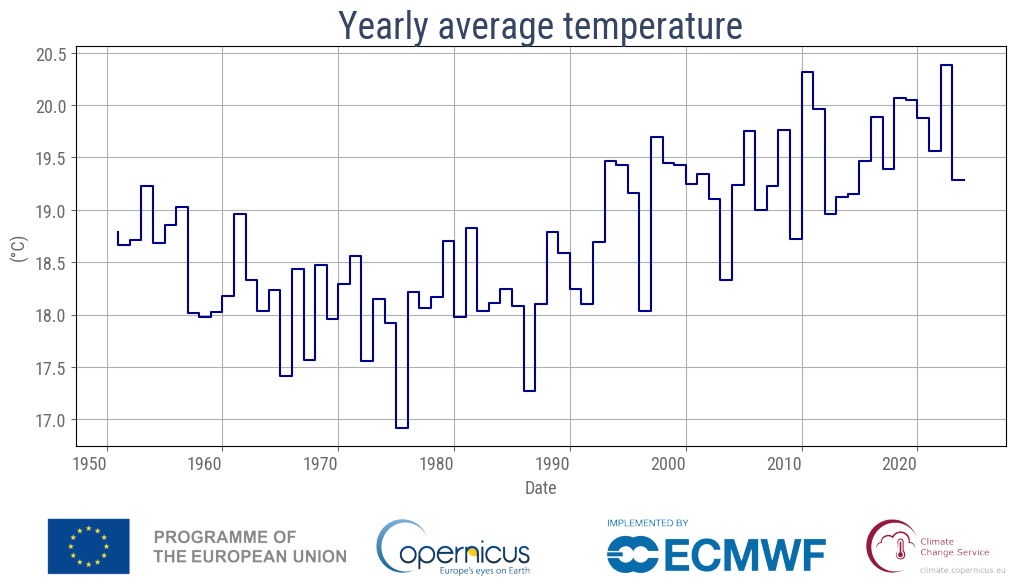

In [19]:
# Example yearly average
yearly_avg = calculate_yearly_value(gdf=spatialmean_climatology_1950_event_studyregion,
                                    value_col=value_col, datetime_col=datetime_col, yearly_value='mean')

# Plot result of yearly values
fig, ax, img_ax = plot_timeserie(data=yearly_avg, value_col=value_col, datetime_col='year', title='Yearly average temperature', x_label='Date', y_label='(°C)', line_style='-', draw_style='steps')

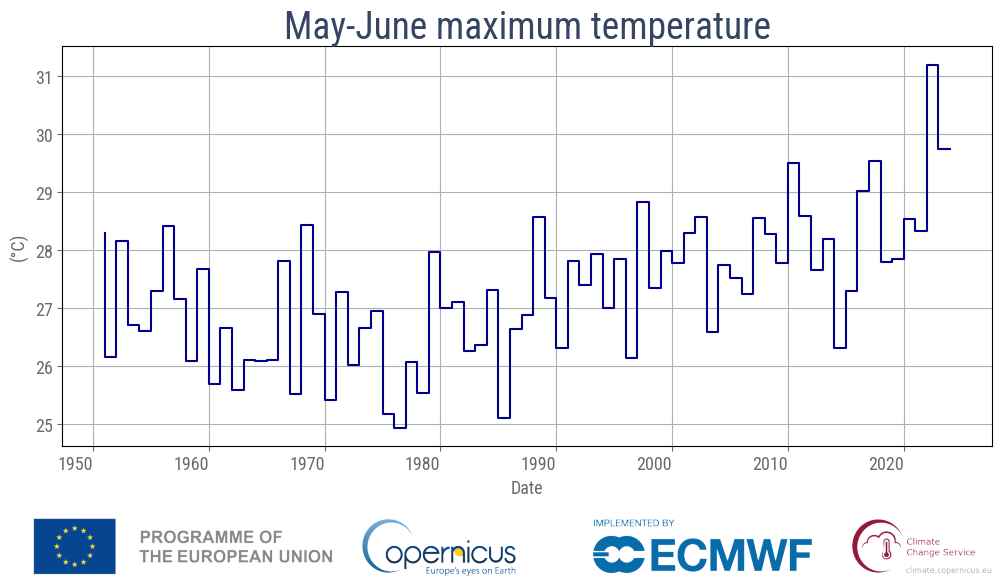

In [20]:
# Example maximum 3 day running mean yearly maximum
running_3d_mean_mj_1950_event_max = calculate_yearly_value(gdf=spatialmean_climatology_1950_event_studyregion,
                                                           value_col=value_col, datetime_col=datetime_col,
                                                           yearly_value='max', padding=3, month_range=(5, 6))

# plot
fig, ax, img_ax = plot_timeserie(data=running_3d_mean_mj_1950_event_max, value_col=value_col, datetime_col='year', title='May-June maximum temperature', x_label='Date', y_label='(°C)', line_style='-', draw_style='steps')

In [21]:
running_3d_mean_mj_1950_event_max

,year,valid_time,t2m
0,1951,1951-06-20,28.297352
1,1952,1952-06-06,26.147647
2,1953,1953-05-22,28.151196
3,1954,1954-06-02,26.710406
4,1955,1955-06-26,26.600015
...,...,...,...
69,2020,2020-06-08,27.844541
70,2021,2021-06-09,28.536992
71,2022,2022-06-07,28.323439
72,2023,2023-06-21,31.203525


### 2.10 Read in station data time series from a CSV file

In [22]:
# # CSV
# separator = ','
# encoding = 'utf-8'
# file_name = 'my_file.csv'   # optionaly add directory
# df = pd.read_csv(file_name, sep=separator, encoding=encoding)

In [23]:
# XLS
# read station data time series from .xls
#xls_station_data = pd.ExcelFile("../data/example.xlsx")
#print(xls_station_data.sheet_names)   # list available sheets
#xls_station_data_sheet1 = pd.read_excel(xls_station_data, "Sheet1")
#xls_station_data_sheet2 = pd.read_excel(xls_station_data, "Sheet2")

In [24]:
#number of days (maximum/mean/minimum of 3 day averages - couple of days from months around selection are needed)
#minimum/maximum / mean
#jan-dec, july-june, specific months (may-june only for example)

### 2.11 Produce a figure of the event "Event Map" (averaged over the temporal definition)


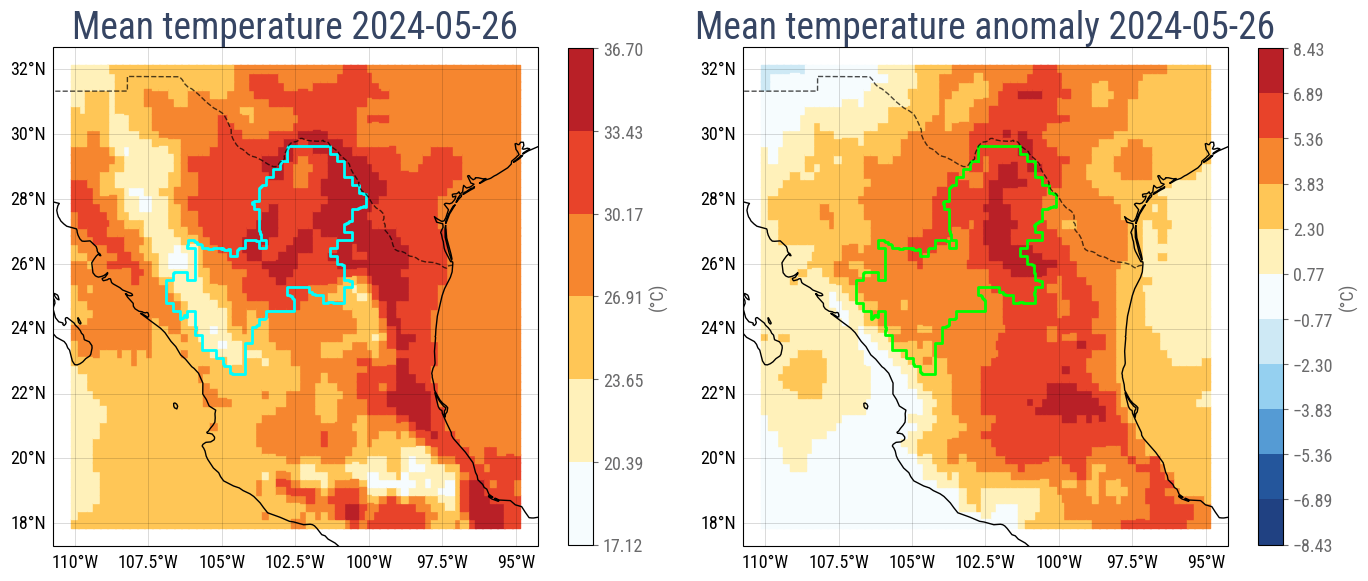

In [36]:
selected_date = datetime(2024, 5, 26)
selected_intersect = subset_gdf(gdf = climatology_event, datetime_col=datetime_col, date_range=(selected_date, selected_date))
selected_intersect_anomaly = subset_gdf(gdf=event_anomaly, datetime_col=datetime_col, date_range=(selected_date, selected_date))

figs, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"projection": ccrs.PlateCarree()})

fig, ax = plot_gdf(selected_intersect, value_col="t2m", ax=axes[0],
                     title=f"Mean temperature {selected_date.strftime('%Y-%m-%d')}",
                     legend_title="(°C)", add_logos=False, polygons=adjusted_polygons, polygon_color="cyan")
fig, ax = plot_gdf(selected_intersect_anomaly, value_col="t2m", ax=axes[1],
                     title=f"Mean temperature anomaly {selected_date.strftime('%Y-%m-%d')}",
                     legend_title="(°C)", add_logos=False, polygons=adjusted_polygons, polygon_color="lime")

plt.tight_layout()
plt.show()

### 2.15 Calculate and save the monthly climatology field to be used for model validation

In [30]:
# Optionally select another period
year = 2024
month = 6   #can be multiple months

month_gdf = subset_gdf(gdf=mean_climatology_1991_2020, datetime_col=datetime_col,
                       year_range=(event_date.year, event_date.year),
                       month_range=(event_date.month, event_date.month))

monthly_avg_gdf = calculate_mean(gdf=month_gdf, value_col=value_col, groupby_col=['longitude', 'latitude', 'geometry'])

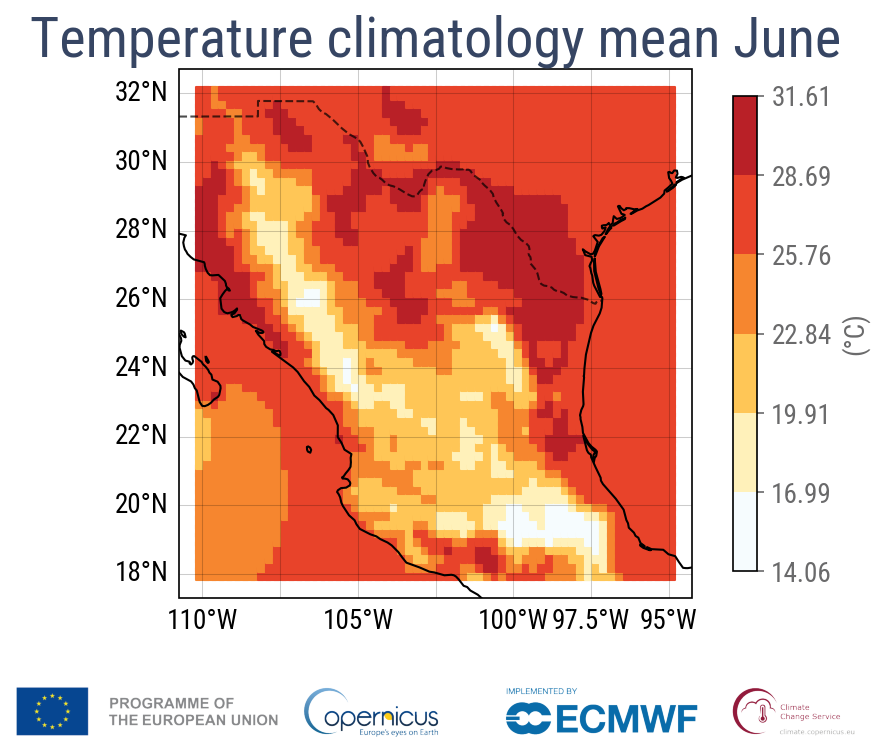

In [31]:
#2.15 Calculate and save the monthly climatology field to be used for model validation
fig, ax, img_ax = plot_gdf(monthly_avg_gdf, title="Temperature climatology mean June",
                           legend_title="(°C)",value_col='t2m',dpi=150)
